# **DATA WRANGLING**

In [ ]:
import pandas as pd

In [ ]:
df=pd.read_csv("/content/TTC Subway Delay Data since 2025.csv")
code=pd.read_csv("/content/Code Descriptions.csv")

In [ ]:
df.head()


,_id,Date,Time,Day,Station,Code,Min Delay,Min Gap,Bound,Line,Vehicle
0,1,2025-01-01,02:10,Wednesday,BATHURST STATION,MUSAN,5,9,E,BD,5227
1,2,2025-01-01,02:30,Wednesday,DUNDAS STATION,MUIRS,0,0,NaN,YU,0
2,3,2025-01-01,02:32,Wednesday,BROADVIEW STATION,PUMST,0,0,E,BD,0
3,4,2025-01-01,02:58,Wednesday,KEELE STATION,EUSC,0,0,W,BD,5293
4,5,2025-01-01,02:58,Wednesday,COXWELL STATION,SUAE,0,0,NaN,BD,0


In [ ]:
df.shape

(40656, 11)

In [ ]:
df.columns
code.columns
code = code.rename(columns={'CODE': 'Code'})
code.columns

Index(['_id', 'Code', 'DESCRIPTION'], dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40656 entries, 0 to 40655
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   _id        40656 non-null  int64 
 1   Date       40656 non-null  object
 2   Time       40656 non-null  object
 3   Day        40656 non-null  object
 4   Station    40656 non-null  object
 5   Code       40656 non-null  object
 6   Min Delay  40656 non-null  int64 
 7   Min Gap    40656 non-null  int64 
 8   Bound      26477 non-null  object
 9   Line       40513 non-null  object
 10  Vehicle    40656 non-null  int64 
dtypes: int64(4), object(7)
memory usage: 3.4+ MB


In [ ]:
df["Date"] = pd.to_datetime(df["Date"])
df["Month_Name"] = df["Date"].dt.month_name()
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month


In [ ]:
df=pd.merge(
    df,
    code[['Code','DESCRIPTION']],
    on='Code',
    how='left'
)
df.head(10)

,_id,Date,Time,Day,Station,Code,Min Delay,Min Gap,Bound,Line,Vehicle,Month_Name,Year,Month,DESCRIPTION
0,1,2025-01-01,02:10,Wednesday,BATHURST STATION,MUSAN,5,9,E,BD,5227,January,2025,1,UNSANITARY VEHICLE
1,2,2025-01-01,02:30,Wednesday,DUNDAS STATION,MUIRS,0,0,NaN,YU,0,January,2025,1,INJURED/ILL CUSTOMER IN STATION â MEDICAL AI...
2,3,2025-01-01,02:32,Wednesday,BROADVIEW STATION,PUMST,0,0,E,BD,0,January,2025,1,ANY STAIRWAY INCIDENT â TRANSPORTED OR MEDIC...
3,4,2025-01-01,02:58,Wednesday,KEELE STATION,EUSC,0,0,W,BD,5293,January,2025,1,SPEED CONTROL EQUIPMENT
4,5,2025-01-01,02:58,Wednesday,COXWELL STATION,SUAE,0,0,NaN,BD,0,January,2025,1,ASSAULT / EMPLOYEE INVOLVED
5,6,2025-01-01,07:59,Wednesday,DONLANDS STATION,TUNOA,5,10,W,BD,5000,January,2025,1,NO OPERATOR AVAILABLE
6,7,2025-01-01,08:13,Wednesday,BLOOR STATION,PUTR,9,0,S,YU,5836,January,2025,1,RAIL RELATED PROBLEM
7,8,2025-01-01,08:15,Wednesday,BLOOR STATION,PUTR,5,0,N,YU,5706,January,2025,1,RAIL RELATED PROBLEM
8,9,2025-01-01,09:14,Wednesday,FINCH STATION,SUDP,0,0,S,YU,5596,January,2025,1,DISORDERLY PATRON
9,10,2025-01-01,09:22,Wednesday,BATHURST STATION,SUUT,0,0,E,BD,5312,January,2025,1,UNAUTHORIZED AT TRACK LEVEL


In [ ]:
df.describe()

,_id,Date,Min Delay,Min Gap,Vehicle,Year,Month
count,40656.000000,40656,40656.000000,40656.000000,40656.000000,40656.000000,40656.000000
mean,20328.500000,2025-10-11 07:23:35.348288256,2.782910,3.820814,3324.257256,2025.366957,5.453291
min,1.000000,2025-01-01 00:00:00,0.000000,0.000000,0.000000,2025.000000,1.000000
25%,10164.750000,2025-05-25 00:00:00,0.000000,0.000000,0.000000,2025.000000,3.000000
50%,20328.500000,2025-10-17 00:00:00,0.000000,0.000000,5132.000000,2025.000000,5.000000
75%,30492.250000,2026-03-04 00:00:00,4.000000,7.000000,5576.000000,2026.000000,8.000000
max,40656.000000,2026-06-30 00:00:00,900.000000,906.000000,9463.000000,2026.000000,12.000000
std,11736.520609,NaN,13.311849,11.999251,2713.928988,0.481981,3.264035


Check null values in the raw data.
Null values in Bound and Line column. How to handle it?

In [ ]:
df.isnull().sum()

,0
_id,0
Date,0
Time,0
Day,0
Station,0
Code,0
Min Delay,0
Min Gap,0
Bound,14179
Line,143


In [ ]:
df[df.Line.isna()]

,_id,Date,Time,Day,Station,Code,Min Delay,Min Gap,Bound,Line,Vehicle,Month_Name,Year,Month,DESCRIPTION
577,578,2025-01-09,17:55,Thursday,BATHURST AND DUPONT,MUIE,0,0,NaN,NaN,0,January,2025,1,INJURED EMPLOYEES
951,952,2025-01-15,11:56,Wednesday,MCCOWAN YARD,SUO,0,0,NaN,NaN,0,January,2025,1,SECURITY OTHER
1065,1066,2025-01-16,00:55,Thursday,ST CLAIR,MUIS,0,0,NaN,NaN,5401,January,2025,1,INJURED/ILL CUSTOMER IN STATION - TRANSPORTED
1162,1163,2025-01-18,14:43,Saturday,SCABOROUGH TOWN CENTRE,PUMEL,0,0,NaN,NaN,0,January,2025,1,ANY ESCL. OR ELEV. INCIDENT â TRANSPORTED OR...
1606,1607,2025-01-24,01:09,Friday,GREENWOOD CAR HOUSE,SUG,0,0,NaN,NaN,5336,January,2025,1,GRAFFITI / SCRATCHITI
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40351,40352,2026-06-27,14:16,Saturday,SPADINA STATION,SUSA,0,0,NaN,NaN,0,June,2026,6,ASSAULT / SEXUAL
40369,40370,2026-06-27,17:44,Saturday,DON MILLS STATION,SUL,0,0,NaN,NaN,0,June,2026,6,NaN
40509,40510,2026-06-29,12:17,Monday,WILSON CARHOUSE,MUSE,0,0,NaN,NaN,0,June,2026,6,NaN
40525,40526,2026-06-29,17:13,Monday,DONLANDS STATION,PUMEL,0,0,NaN,NaN,0,June,2026,6,ANY ESCL. OR ELEV. INCIDENT â TRANSPORTED OR...


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.nunique()

,0
_id,40656
Date,546
Time,1437
Day,7
Station,1195
Code,138
Min Delay,133
Min Gap,132
Bound,5
Line,34


In [ ]:
df.Year.value_counts()

,count
Year,
2025,25737
2026,14919


In [ ]:
df.groupby([df.Year])['Month_Name'].value_counts()

Year  Month_Name
2025  August        2719
      February      2274
      December      2242
      November      2215
      May           2175
      July          2122
      April         2117
      January       2106
      October       2027
      March         1986
      June          1941
      September     1813
2026  April         2719
      June          2638
      May           2633
      January       2481
      March         2400
      February      2048
Name: count, dtype: int64

In [ ]:
df.Day

,Day
0,Wednesday
1,Wednesday
2,Wednesday
3,Wednesday
4,Wednesday
...,...
40651,Tuesday
40652,Tuesday
40653,Tuesday
40654,Tuesday


In [ ]:
df.Bound.value_counts()

,count
Bound,
S,7146
E,6760
W,6320
N,6194
B,57


In [ ]:
df.Line.value_counts()

,count
Line,
YU,20716
BD,17649
SHP,1581
YU/BD,455
YUS/BD,44
YUS,12
YU/BD/SHP,8
BD/YU,7
SRT,5


# **EDA**

In [ ]:
#total delays with year
yr = int(input("Enter Year for analysis :"))
yr_df = df[df['Year'] == yr]
#yr_df = df[(df['Year'] == yr) & (df['Min Delay'] != 0)]
yr_delays = yr_df['Min Delay'].count()
print(f"Total delays in {yr}: {yr_delays}")
#total dealys by month
mo_wise = yr_df.groupby('Month_Name')['Min Delay'].count()
print(mo_wise.sort_values(ascending=False))

Enter Year for analysis :2025
Total delays in 2025: 25737
Month_Name
August       2719
February     2274
December     2242
November     2215
May          2175
July         2122
April        2117
January      2106
October      2027
March        1986
June         1941
September    1813
Name: Min Delay, dtype: int64


In [ ]:
#avg delay time
df_nn=yr_df[yr_df['Min Delay']!= 0]
#print(df_nn['Min Delay'].describe())
avg_delay = df_nn['Min Delay'].mean()
print(f"Average delay time: {avg_delay:.2f} minutes")
#avg dealy by month
mo_wise_avg = df_nn.groupby('Month_Name')['Min Delay'].mean()
mo_wise_nn = df_nn.groupby('Month_Name')['Min Delay'].count()
print(mo_wise_avg.sort_values(ascending=False))

Average delay time: 7.78 minutes
Month_Name
February     9.559433
July         8.135174
April        8.062583
January      7.897277
March        7.871411
June         7.706325
December     7.669834
May          7.430917
November     7.418465
October      7.315341
August       6.919028
September    6.828990
Name: Min Delay, dtype: float64


In [171]:
#Month and code with most delays
lc_delays=df_nn.groupby(['Month','Month_Name','Code','DESCRIPTION'])['Min Delay'].agg(['count','sum','mean','max'])

val=lc_delays.sort_values(by='sum',ascending=False).groupby('Month_Name').head(3)
val.sort_values(by=['Month','sum'],ascending=[True, False] )


count  \
Month Month_Name Code  DESCRIPTION                                                 
1     January    SUDP  DISORDERLY PATRON                                     159   
                 SUUT  UNAUTHORIZED AT TRACK LEVEL                            32   
                 MUIR  INJURED/ILL CUSTOMER ON TRAIN â MEDICAL AID R...     51   
2     February   MUWEA WEATHER REPORTS / RELATED PROBLEMS                    137   
                 SUDP  DISORDERLY PATRON                                     116   
                 SUO   SECURITY OTHER                                         39   
3     March      SUDP  DISORDERLY PATRON                                     102   
                 MUPR1 PRIORITY ONE â TRAIN IN CONTACT WITH PERSON           6   
                 MUI   INJURED/ILL CUSTOMER ON TRAIN â TRANSPORTED          39   
4     April      MUI   INJURED/ILL CUSTOMER ON TRAIN â TRANSPORTED          32   
                 SUDP  DISORDERLY PATRON                                      83   
                 SUUT  UNAUTHORIZED AT TRACK LEVEL                            33   
5     May        SUDP  DISORDERLY PATRON                                      99   
                 MUIR  INJURED/ILL CUSTOMER ON TRAIN â MEDICAL AID R...     64   
                 PUTWZ WORK ZONES PROBLEMS â TRACK                          38   
6     June       SUDP  DISORDERLY PATRON                                      82   
                 SUUT  UNAUTHORIZED AT TRACK LEVEL                            22   
                 MUIR  INJURED/ILL CUSTOMER ON TRAIN â MEDICAL AID R...     41   
7     July       SUDP  DISORDERLY PATRON                                      96   
                 MUIR  INJURED/ILL CUSTOMER ON TRAIN â MEDICAL AID R...     46   
                 SUO   SECURITY OTHER                                         27   
8     August     SUDP  DISORDERLY PATRON                                      75   
                 MUIR  INJURED/ILL CUSTOMER ON TRAIN â MEDICAL AID R...     58   
                 MUPAA PAA â NO TROUBLE FOUND                               90   
9     September  MUIR  INJURED/ILL CUSTOMER ON TRAIN â MEDICAL AID R...     58   
                 SUDP  DISORDERLY PATRON                                      68   
                 PUOPO OPTO (COMMUNICATIONS) TRAIN DOOR MONITORING            48   
10    October    SUO   SECURITY OTHER                                         38   
                 SUDP  DISORDERLY PATRON                                      63   
                 SUUT  UNAUTHORIZED AT TRACK LEVEL                            32   
11    November   SUDP  DISORDERLY PATRON                                      94   
                 MUIR  INJURED/ILL CUSTOMER ON TRAIN â MEDICAL AID R...     75   
                 PUTS  STRUCTURE RELATED PROBLEM                              12   
12    December   SUDP  DISORDERLY PATRON                                     120   
                 MUIR  INJURED/ILL CUSTOMER ON TRAIN â MEDICAL AID R...     66   
                 MUPLB FIRE/SMOKE PLAN B â SOURCE TTC (TRACK LEVEL)          6   

                                                                            sum  \
Month Month_Name Code  DESCRIPTION                                                
1     January    SUDP  DISORDERLY PATRON                                   1093   
                 SUUT  UNAUTHORIZED AT TRACK LEVEL                          429   
                 MUIR  INJURED/ILL CUSTOMER ON TRAIN â MEDICAL AID R...   374   
2     February   MUWEA WEATHER REPORTS / RELATED PROBLEMS                  2619   
                 SUDP  DISORDERLY PATRON                                    747   
                 SUO   SECURITY OTHER                                       422   
3     March      SUDP  DISORDERLY PATRON                                    649   
                 MUPR1 PRIORITY ONE â TRAIN IN CONTACT WITH PERSON        529   
                 MUI   INJURED/ILL CUSTOMER ON TRAIN

In [ ]:
#station with most delays
stn_delays=yr_df.groupby('Station')['Min Delay'].agg(['count','sum','mean','max'])
print(stn_delays.sort_values(by='count',ascending=False).head(10))


                    count   sum      mean  max
Station                                       
BLOOR STATION         915  1691  1.848087   58
KENNEDY BD STATION    866  1851  2.137413  202
FINCH STATION         791  1477  1.867257   88
KIPLING STATION       783  2050  2.618135  120
EGLINTON STATION      660  2822  4.275758  807
WILSON STATION        620  2146  3.461290  119
WARDEN STATION        544  1484  2.727941   68
YONGE BD STATION      512  1284  2.507812   85
DUNDAS STATION        501   860  1.716567   63
UNION STATION         473   883  1.866808   80


In [ ]:
#lines with most delays
line_delays=yr_df.groupby('Line')['Min Delay'].agg(['count','sum','mean','max'])
line_delays.sort_values(by='count',ascending=False).head(10)


,count,sum,mean,max
Line,,,,
YU,13082,40232,3.075371,900
BD,11145,27404,2.458860,202
SHP,1065,3115,2.924883,167
YU/BD,319,0,0.000000,0
YUS/BD,16,0,0.000000,0
YUS,4,0,0.000000,0
BD/YUS,3,0,0.000000,0
YU/ BD,3,0,0.000000,0
BD/YU,3,0,0.000000,0


In [ ]:
#Line and station with most delays
ls_delays=df_nn.groupby(['Line','Station','Code','DESCRIPTION'])['Min Delay'].agg(['count','sum','mean','max'])
ls_delays.sort_values(by='count',ascending=False).head(10)

count  \
Line Station                Code  DESCRIPTION                                          
YU   WILSON STATION         MUWEA WEATHER REPORTS / RELATED PROBLEMS              64   
     BLOOR STATION          SUDP  DISORDERLY PATRON                               62   
     NORTH YORK CTR STATION PUOPO OPTO (COMMUNICATIONS) TRAIN DOOR MONITORING     49   
BD   YONGE BD STATION       SUDP  DISORDERLY PATRON                               47   
YU   LAWRENCE STATION       PUOPO OPTO (COMMUNICATIONS) TRAIN DOOR MONITORING     43   
     KING STATION           PUTR  RAIL RELATED PROBLEM                            43   
     WELLESLEY STATION      MUPAA PAA â NO TROUBLE FOUND                        42   
     EGLINTON STATION       SUDP  DISORDERLY PATRON                               39   
     YORKDALE STATION       PUOPO OPTO (COMMUNICATIONS) TRAIN DOOR MONITORING     37   
     BLOOR STATION          MUPAA PAA â NO TROUBLE FOUND                        35   

                                                                               sum  \
Line Station                Code  DESCRIPTION                                        
YU   WILSON STATION         MUWEA WEATHER REPORTS / RELATED PROBLEMS           199   
     BLOOR STATION          SUDP  DISORDERLY PATRON                            268   
     NORTH YORK CTR STATION PUOPO OPTO (COMMUNICATIONS) TRAIN DOOR MONITORING  217   
BD   YONGE BD STATION       SUDP  DISORDERLY PATRON                            208   
YU   LAWRENCE STATION       PUOPO OPTO (COMMUNICATIONS) TRAIN DOOR MONITORING  322   
     KING STATION           PUTR  RAIL RELATED PROBLEM                         325   
     WELLESLEY STATION      MUPAA PAA â NO TROUBLE FOUND                     194   
     EGLINTON STATION       SUDP  DISORDERLY PATRON                            263   
     YORKDALE STATION       PUOPO OPTO (COMMUNICATIONS) TRAIN DOOR MONITORING  298   
     BLOOR STATION          MUPAA PAA â NO TROUBLE FOUND                     146   

                                                                                   mean  \
Line Station                Code  DESCRIPTION                                             
YU   WILSON STATION         MUWEA WEATHER REPORTS / RELATED PROBLEMS           3.109375   
     BLOOR STATION          SUDP  DISORDERLY PATRON                            4.322581   
     NORTH YORK CTR STATION PUOPO OPTO (COMMUNICATIONS) TRAIN DOOR MONITORING  4.428571   
BD   YONGE BD STATION       SUDP  DISORDERLY PATRON                            4.425532   
YU   LAWRENCE STATION       PUOPO OPTO (COMMUNICATIONS) TRAIN DOOR MONITORING  7.488372   
     KING STATION           PUTR  RAIL RELATED PROBLEM                         7.558140   
     WELLESLEY STATION      MUPAA PAA â NO TROUBLE FOUND                     4.619048   
     EGLINTON STATION       SUDP  DISORDERLY PATRON                            6.743590   
     YORKDALE STATION       PUOPO OPTO (COMMUNICATIONS) TRAIN DOOR MONITORING  8.054054   
     BLOOR STATION          MUPAA PAA â NO TROUBLE FOUND                     4.171429   

                                                                               max  
Line Station                Code  DESCRIPTION                                       
YU   WILSON STATION         MUWEA WEATHER REPORTS / RELATED PROBLEMS             5  
     BLOOR STATION          SUDP  DISORDERLY PATRON                              8  
     NORTH YORK CTR STATION PUOPO OPTO (COMMUNICATIONS) TRAIN DOOR MONITORING   13  
BD   YONGE BD STATION       SUDP  DISORDERLY PATRON                              9  
YU   LAWRENCE STATION       PUOPO OPTO (COMMUNICATIONS) TRAIN DOOR MONITORING   20  
     KING STATION           PUTR  RAIL RELATED PROBLEM                          16  
     WELLESLEY STATION      MUPAA PAA â NO TROUBLE FOUND                      16  
     EGLINTON STATION       SUDP  DISORDERLY PATRON                             19  
     YORKDALE STATION       PUOPO OPTO (COMMUN

In [ ]:
#codes causing delays
code_delays=yr_df.groupby(['Code','DESCRIPTION'])['Min Delay'].agg(['count','sum','mean','max'])
code_delays.sort_values(by='sum',ascending=False).head(10)

,,count,sum,mean,max
Code,DESCRIPTION,,,,
SUDP,DISORDERLY PATRON,2944,7646,2.597147,110
MUIR,INJURED/ILL CUSTOMER ON TRAIN â MEDICAL AID REFUSED,841,4797,5.703924,27
SUUT,UNAUTHORIZED AT TRACK LEVEL,571,3917,6.859895,79
MUI,INJURED/ILL CUSTOMER ON TRAIN â TRANSPORTED,412,3785,9.186893,90
SUO,SECURITY OTHER,1679,3418,2.035736,78
PUOPO,OPTO (COMMUNICATIONS) TRAIN DOOR MONITORING,1258,3406,2.707472,29
MUPAA,PAA â NO TROUBLE FOUND,1367,2955,2.161668,16
MUWEA,WEATHER REPORTS / RELATED PROBLEMS,211,2745,13.009479,900
PUTWZ,WORK ZONES PROBLEMS â TRACK,244,2333,9.561475,97


In [ ]:
#Null value analysis
df_null=yr_df[yr_df['Min Delay'] == 0]
#null_info = df_null.groupby(['Code'])['Min Delay'].count()
null_info = df_null.groupby(['Line','Code','DESCRIPTION'])['Min Delay'].count()
null_info.sort_values(ascending=False).head(10)

Line  Code   DESCRIPTION                                            
YU    MUIS   INJURED/ILL CUSTOMER IN STATION - TRANSPORTED              1287
      SUDP   DISORDERLY PATRON                                          1024
BD    MUIS   INJURED/ILL CUSTOMER IN STATION - TRANSPORTED               951
      MUSC   SI SPEED CONTROL                                            736
      SUDP   DISORDERLY PATRON                                           714
YU    SUO    SECURITY OTHER                                              669
BD    SUO    SECURITY OTHER                                              580
YU    MUIRS  INJURED/ILL CUSTOMER IN STATION â MEDICAL AID REFUSED     571
      PUOPO  OPTO (COMMUNICATIONS) TRAIN DOOR MONITORING                 570
      TUNCA  NO COLLECTOR AVAILABLE                                      558
Name: Min Delay, dtype: int64

In [184]:
#vehicles and codes
vh_df=yr_df[yr_df['Vehicle'] != 0]
filt_df = vh_df[
    vh_df.groupby('Vehicle')['Vehicle'].transform('size') > 60
].reset_index(drop=True)

veh_codes=filt_df.groupby(['Vehicle' ,'DESCRIPTION','Month_Name'])['Min Delay'].agg(['count','sum','mean','max'])
veh=veh_codes.sort_values(by='sum',ascending=False).groupby('Vehicle').head(3)
veh.sort_values(by=['Vehicle','sum'],ascending=[True, False] )

count  \
Vehicle DESCRIPTION                                        Month_Name          
5441    PRIORITY ONE â TRAIN IN CONTACT WITH PERSON      January         1   
        DEBRIS AT TRACK LEVEL - CONTROLLABLE               November        1   
        OPTO (COMMUNICATIONS) TRAIN DOOR MONITORING        June            9   
5541    TRACK SWITCH FAILURE â S/E/C RELATED PROBLEM     October         1   
        DISORDERLY PATRON                                  January         5   
        OPTO (COMMUNICATIONS) TRAIN DOOR MONITORING        February        3   
5581    UNAUTHORIZED AT TRACK LEVEL                        June            1   
        TRANSIT CONTROL RELATED â TOWER CONTROLLER ERROR April           1   
        UNAUTHORIZED AT TRACK LEVEL                        January         2   
5676    SCADA RELATED PROBLEMS                             October         2   
        UNAUTHORIZED AT TRACK LEVEL                        October         1   
        OPERATOR NOT IN POSTION                            June            1   
5746    INJURED/ILL CUSTOMER ON TRAIN â TRANSPORTED      April           2   
        UNAUTHORIZED AT TRACK LEVEL                        January         1   
        INJURED/ILL CUSTOMER ON TRAIN â MEDICAL AID R... September       2   
5766    PRIORITY ONE â TRAIN IN CONTACT WITH PERSON      August          1   
        TRANSPORTATION OTHER                               January         2   
        OPTO (COMMUNICATIONS) TRAIN DOOR MONITORING        February        3   
5876    UNAUTHORIZED AT TRACK LEVEL                        January         1   
        DISORDERLY PATRON                                  May             2   
        OPTO (COMMUNICATIONS) TRAIN DOOR MONITORING        November        8   
5886    DOOR PROBLEMS RE:FAULTY EQUIPMENT                  August          1   
        DISORDERLY PATRON                                  December        3   
        TRANSIT CONTROL RELATED â TOWER CONTROLLER ERROR April           1   
5896    UNAUTHORIZED AT TRACK LEVEL                        May             1   
        WORK ZONES PROBLEMS â TRACK                      February        1   
        OPTO (COMMUNICATIONS) TRAIN DOOR MONITORING        November        8   
6061    UNAUTHORIZED AT TRACK LEVEL                        June            1   
        RAIL RELATED PROBLEM                               November        1   
        UNAUTHORIZED AT TRACK LEVEL                        December        2   
6136    ASSUALT / PATRON INVOLVED                          January         2   
        SIGNALS AXLE COUNTER BLOCK FAILURE                 July            1   
        DOOR PROBLEMS RE:FAULTY EQUIPMENT                  February        2   
6156    SIGNAL CONTROL                                     September       1   
        INJURED/ILL CUSTOMER ON TRAIN â TRANSPORTED      August          1   
        SI SPEED CONTROL                                   September       2   
6171    SIGNALS â TRAIN STOPS                            November        1   
        TRACTION POWER RAIL RELATED PROBLEMS               April           1   
        TRANSPORTATION OTHER                               September       1   
6176    TRACK SWITCH FAILURE â S/E/C RELATED PROBLEM     June            1   
        SECURITY OTHER                                     October         1   
        TRANSPORTATION OTHER                               December        1   
6181    WORK ZONES PROBLEMS â TRACK                      October         1   
                                                           May             2   
        SPEED CONTROL EQUIPMENT                            November        5   
6191    FIRE/SMOKE PLAN B â SOURCE TTC (TRACK LEVEL)     February        1   
        DISORDERLY PATRON                                  October         1   
        UNAUTHORIZED AT TRACK LEVEL                        February        1   

                                                                      

In [ ]:
#line and vehicles causing delays
veh_delays=yr_df.groupby(['Line','Vehicle'])['Min Delay'].agg(['count','sum','mean','max'])
veh_delays.sort_values(by='count',ascending=False).head(20)

count  sum      mean  max
Line  Vehicle                           
YU    0         5665  556  0.098147   39
BD    0         4338  427  0.098432   64
SHP   0          362   56  0.154696   30
YU/BD 0          318    0  0.000000    0
SHP   6181        72  223  3.097222   30
YU    5896        68  358  5.264706   61
      5746        67  296  4.417910   22
      5876        65  273  4.200000   29
SHP   6171        65  433  6.661538  156
      6156        64  299  4.671875  149
YU    6061        64  280  4.375000   21
      5441        63  316  5.015873   90
      5886        63  467  7.412698   63
SHP   6176        63  258  4.095238   65
YU    5766        61  416  6.819672   98
SHP   6191        61  329  5.393443   87
YU    5676        61  352  5.770492   40
      6136        61  290  4.754098   26
      5581        61  261  4.278689   29
      5421        59  228  3.864407   15

In [ ]:
yr_df[["Min Delay", "Min Gap", "Month", "Vehicle"]].corr()


,Min Delay,Min Gap,Month,Vehicle
Min Delay,1.000000,0.961362,-0.022486,0.205470
Min Gap,0.961362,1.000000,-0.023357,0.275157
Month,-0.022486,-0.023357,1.000000,0.001777
Vehicle,0.205470,0.275157,0.001777,1.000000


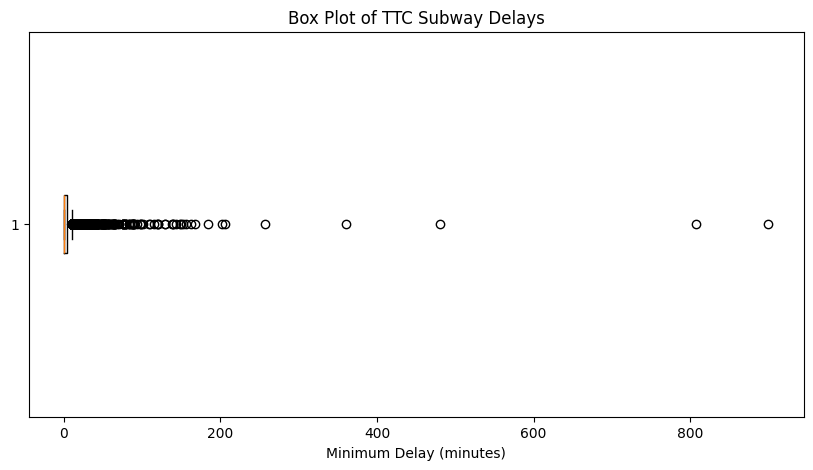

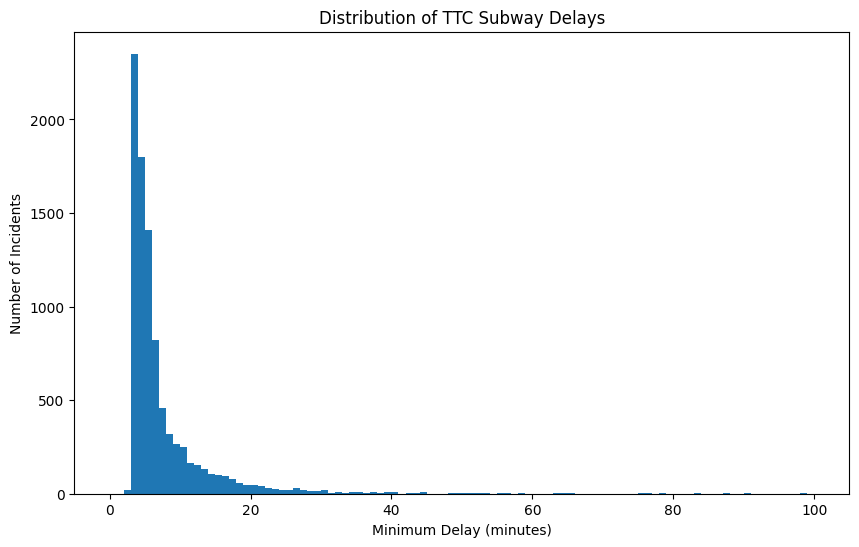

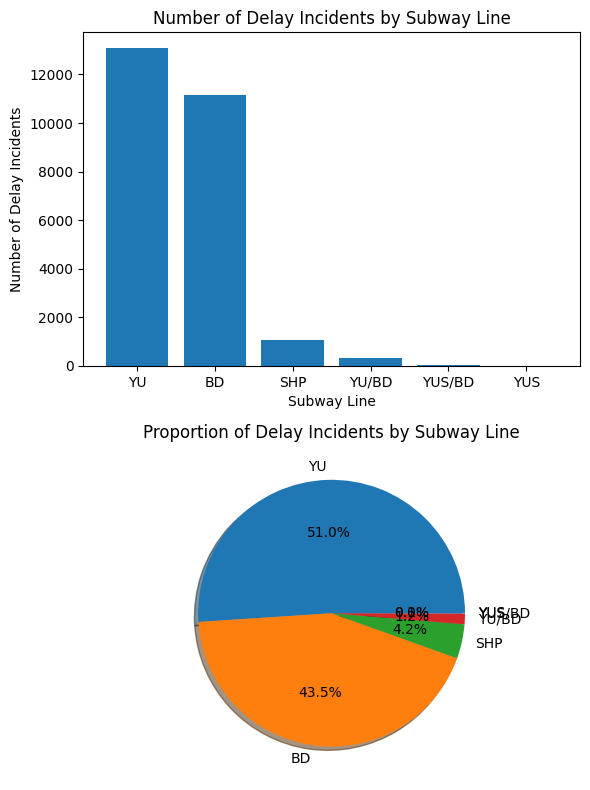

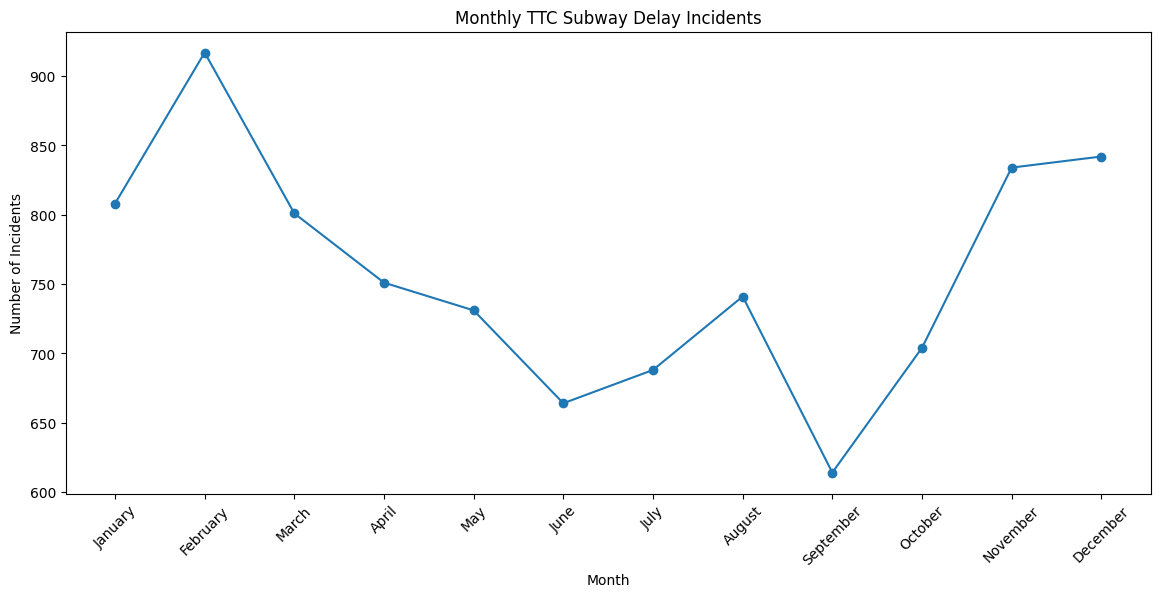

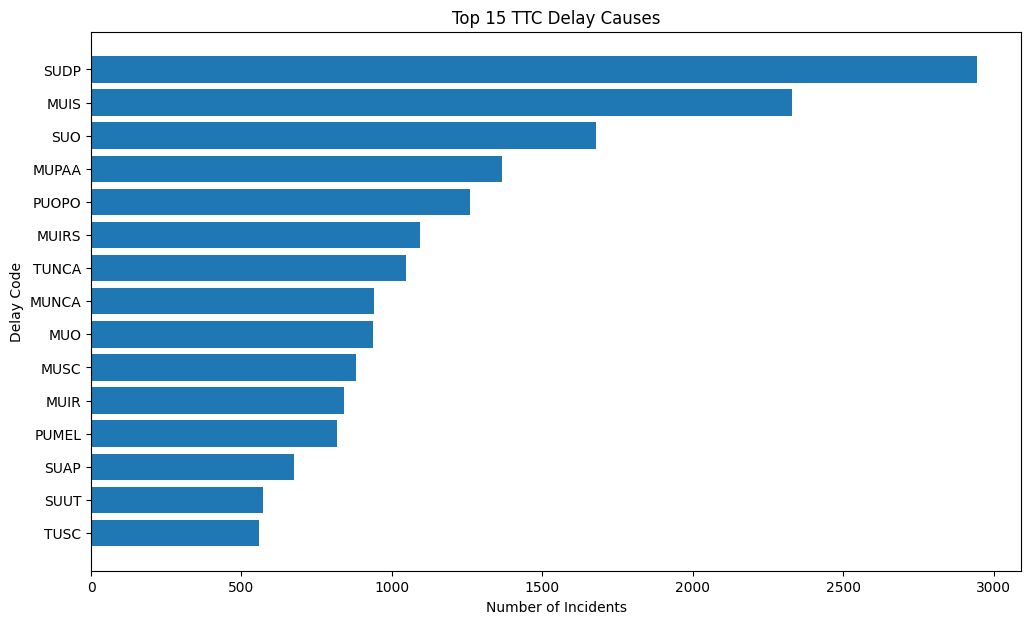

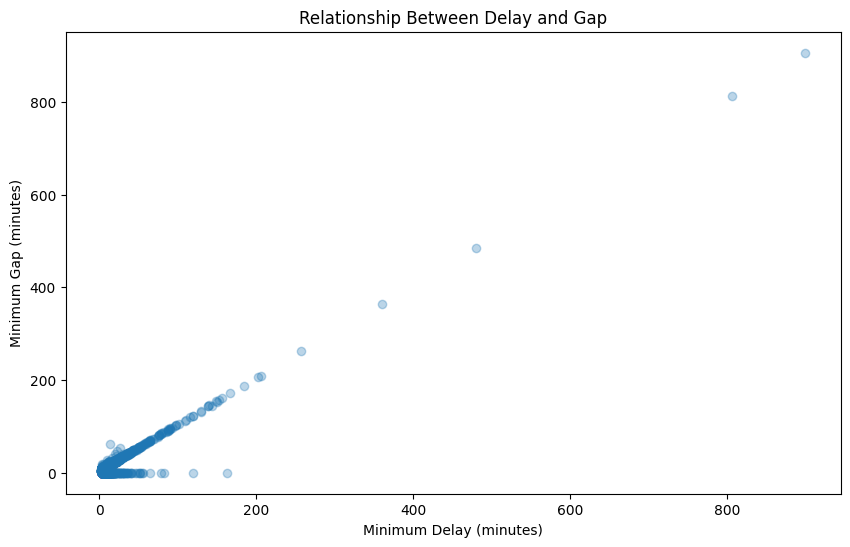

In [ ]:
import matplotlib.pyplot as plt

#Boxplot delays
plt.figure(figsize=(10, 5))

plt.boxplot(yr_df["Min Delay"].dropna(), vert=False)

plt.xlabel("Minimum Delay (minutes)")
plt.title("Box Plot of TTC Subway Delays")

plt.show()

#Distribution
plt.figure(figsize=(10, 6))

plt.hist(df_nn["Min Delay"],range=(0,100) , bins=100)

plt.xlabel("Minimum Delay (minutes)")
plt.ylabel("Number of Incidents")
plt.title("Distribution of TTC Subway Delays")

plt.show()


#Delay by line
fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, figsize=(6, 8))

line_counts = yr_df["Line"].value_counts().head(6)

ax1.bar(line_counts.index, line_counts.values)
ax1.set_xlabel("Subway Line")
ax1.set_ylabel("Number of Delay Incidents")
ax1.set_title("Number of Delay Incidents by Subway Line")

ax2.pie(line_counts.values, labels=line_counts.index, shadow=True , autopct="%1.1f%%")
ax2.set_title("Proportion of Delay Incidents by Subway Line")

plt.tight_layout()
plt.show()


#monthly incidents
months_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
mo_wise_nn = mo_wise_nn.reindex(months_order).dropna()

plt.figure(figsize=(14, 6))

plt.plot(
    mo_wise_nn.index,
    mo_wise_nn.values,
    marker="o"
)

plt.xlabel("Month")
plt.ylabel("Number of Incidents")
plt.title("Monthly TTC Subway Delay Incidents")

plt.xticks(rotation=45)

plt.show()

#codess
code_counts = yr_df["Code"].value_counts()
top_codes = code_counts.head(15)

plt.figure(figsize=(12, 7))

plt.barh(
    top_codes.index[::-1],
    top_codes.values[::-1]
)

plt.xlabel("Number of Incidents")
plt.ylabel("Delay Code")
plt.title("Top 15 TTC Delay Causes")

plt.show()

#delay vc gap
plt.figure(figsize=(10, 6))

plt.scatter(
    df_nn["Min Delay"],
    df_nn["Min Gap"],
    alpha=0.3
)

plt.xlabel("Minimum Delay (minutes)")
plt.ylabel("Minimum Gap (minutes)")
plt.title("Relationship Between Delay and Gap")

plt.show()

In [ ]:
out_df=yr_df[yr_df['Min Delay']>180]
out_df[['Day','Time','Line','Station','DESCRIPTION','Month_Name','Min Delay']].sort_values(by='Min Delay',ascending=False)

,Day,Time,Line,Station,DESCRIPTION,Month_Name,Min Delay
3320,Sunday,11:03,YU,SHEPPARD WEST STATION,WEATHER REPORTS / RELATED PROBLEMS,February,900
3308,Sunday,09:18,YU,EGLINTON STATION,WEATHER REPORTS / RELATED PROBLEMS,February,807
23172,Wednesday,18:20,YU,SHEPPARD TO EGLINTON,STRUCTURE RELATED PROBLEM,November,480
1395,Wednesday,04:41,YU,YORKDALE STATION,TRACTION POWER RAIL RELATED PROBLEMS,January,360
3355,Sunday,16:56,YU,ROSEDALE STATION,WEATHER REPORTS / RELATED PROBLEMS,February,257
24209,Wednesday,09:32,YU,LAWRENCE STATION,FIRE/SMOKE PLAN B â SOURCE TTC (TRACK LEVEL),December,206
6426,Tuesday,19:42,BD,KENNEDY BD STATION,TRACTION POWER RAIL RELATED PROBLEMS,April,202
25214,Tuesday,19:09,BD,COXWELL STATION APPROA,TRACTION POWER OR RELATED COMPONENTS FAILURE,December,184


/tmp/ipykernel_6523/2271354712.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  yr_df['Hour'] = pd.to_datetime(yr_df['Time'], format='%H:%M', errors='coerce').dt.hour


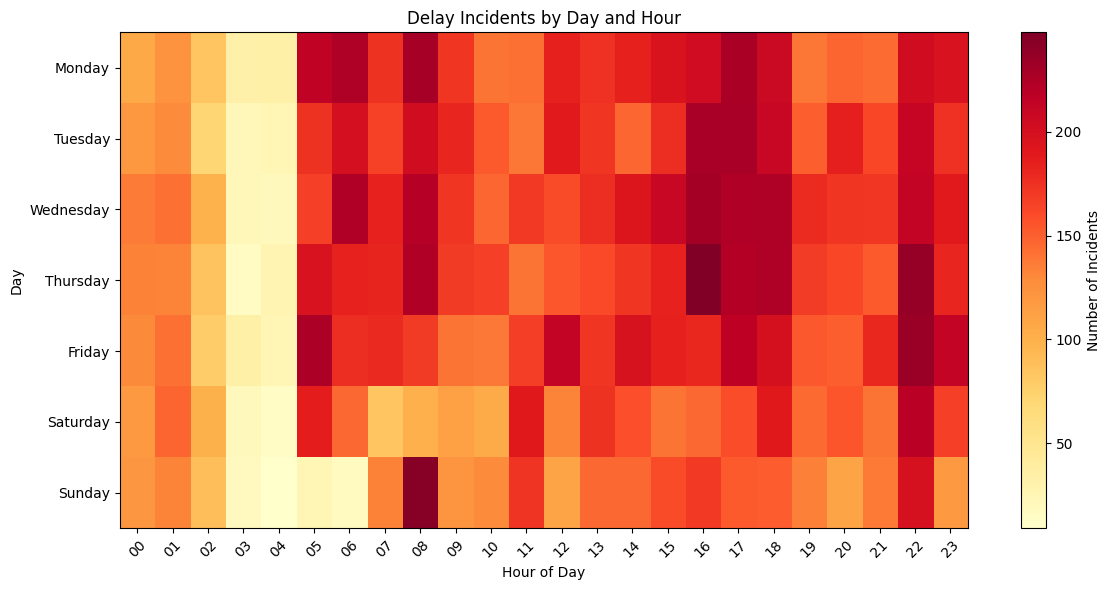

In [ ]:
#Heatmap
# Convert the Time column into an hour number
yr_df['Hour'] = pd.to_datetime(yr_df['Time'], format='%H:%M', errors='coerce').dt.hour

# Count delay incidents for each day and hour
day_hour = yr_df.groupby(['Day', 'Hour']).size().unstack(fill_value=0)

# Set the days in the correct order
days = [
    'Monday',
    'Tuesday',
    'Wednesday',
    'Thursday',
    'Friday',
    'Saturday',
    'Sunday'
]

# Reorder the rows so the days appear Monday to Sunday
day_hour = day_hour.reindex(days, fill_value=0)

# Make sure all 24 hours are included
day_hour = day_hour.reindex(columns=range(24), fill_value=0)

# Create the heatmap
plt.figure(figsize=(12, 6))

plt.imshow(day_hour, aspect='auto', cmap='YlOrRd')

plt.title('Delay Incidents by Day and Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Day')

# Label the 24 hours from 00 to 23
plt.xticks(range(24), [f'{hour:02d}' for hour in range(24)], rotation=45)

# Label the days of the week
plt.yticks(range(7), days)

# Add a legend showing the number of incidents
plt.colorbar(label='Number of Incidents')

plt.tight_layout()
plt.show()